# 01 · Fraud EDA: Data Quality & Exploratory Analysis

**Dataset:** PaySim synthetic mobile-money transactions (`data/raw/PS_20174392719_1491204439457_log.csv`)

**Goal of this notebook**
1. Verify the data is what we think it is (schema, types, nulls, duplicates, impossible values).
2. Answer the core investigation questions about *how fraud behaves* in this data.
3. Record data-quality issues that Phase 2 (cleaning) must resolve.

> **Rule:** every "Finding" cell is written *after* running the code above it, using the numbers printed, never from assumptions or external write-ups of PaySim.

In [1]:
import logging
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(PROJECT_ROOT))

from src.data_loader import load_paysim
from src import data_validation as dv

logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(name)s | %(message)s")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
pd.set_option("display.max_columns", 50)

# Consistent class colours across every chart (colour-blind-safe pair, validated).
LEGIT, FRAUD = "#2a78d6", "#eb6834"
plt.rcParams.update({
    "figure.figsize": (10, 4.5), "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "axes.titleweight": "bold",
})

## 1. Load the raw data
No rows are modified or dropped at load time.

In [2]:
df = load_paysim()
df.head()

INFO | src.data_loader | Loading PaySim data from /Users/kiruthiga/Downloads/ai-safety-fraud-risk-platform/data/raw/PS_20174392719_1491204439457_log.csv


INFO | src.data_loader | Loaded 6,362,620 rows x 11 columns


,step,type,amount,name_orig,old_balance_orig,new_balance_orig,name_dest,old_balance_dest,new_balance_dest,is_fraud,is_flagged_fraud
0,1,PAYMENT,"9,839.6400",C1231006815,"170,136.0000","160,296.3600",M1979787155,0.0000,0.0000,0,0
1,1,PAYMENT,"1,864.2800",C1666544295,"21,249.0000","19,384.7200",M2044282225,0.0000,0.0000,0,0
2,1,TRANSFER,181.0000,C1305486145,181.0000,0.0000,C553264065,0.0000,0.0000,1,0
3,1,CASH_OUT,181.0000,C840083671,181.0000,0.0000,C38997010,"21,182.0000",0.0000,1,0
4,1,PAYMENT,"11,668.1400",C2048537720,"41,554.0000","29,885.8600",M1230701703,0.0000,0.0000,0,0


## 2. Data quality
### 2.1 Shape, columns and data types

In [3]:
quality = dv.run_data_quality_checks(df)

print(f"Shape: {quality['shape'][0]:,} rows x {quality['shape'][1]} columns")
print("Schema check:", quality["schema"])
pd.Series(quality["dtypes"], name="dtype").to_frame()

INFO | src.data_validation | Data-quality checks complete: 6,362,620 rows, 0 duplicates, imbalance 773.7:1


Shape: 6,362,620 rows x 11 columns
Schema check: {'missing_columns': [], 'unexpected_columns': [], 'is_valid': True}


,dtype
step,int32
type,category
amount,float64
name_orig,string
old_balance_orig,float64
new_balance_orig,float64
name_dest,string
old_balance_dest,float64
new_balance_dest,float64
is_fraud,int8


In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
step,"6,362,620.0000",NaN,NaN,NaN,243.3972,142.3320,1.0000,156.0000,239.0000,335.0000,743.0000
type,6362620,5,CASH_OUT,2237500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
amount,"6,362,620.0000",NaN,NaN,NaN,"179,861.9035","603,858.2315",0.0000,"13,389.5700","74,871.9400","208,721.4775","92,445,516.6400"
name_orig,6362620,6353307,C1902386530,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
old_balance_orig,"6,362,620.0000",NaN,NaN,NaN,"833,883.1041","2,888,242.6730",0.0000,0.0000,"14,208.0000","107,315.1750","59,585,040.3700"
new_balance_orig,"6,362,620.0000",NaN,NaN,NaN,"855,113.6686","2,924,048.5030",0.0000,0.0000,0.0000,"144,258.4100","49,585,040.3700"
name_dest,6362620,2722362,C1286084959,113,NaN,NaN,NaN,NaN,NaN,NaN,NaN
old_balance_dest,"6,362,620.0000",NaN,NaN,NaN,"1,100,701.6665","3,399,180.1130",0.0000,0.0000,"132,705.6650","943,036.7075","356,015,889.3500"
new_balance_dest,"6,362,620.0000",NaN,NaN,NaN,"1,224,996.3982","3,674,128.9421",0.0000,0.0000,"214,661.4400","1,111,909.2500","356,179,278.9200"
is_fraud,"6,362,620.0000",NaN,NaN,NaN,0.0013,0.0359,0.0000,0.0000,0.0000,0.0000,1.0000


### 2.2 Missing values and duplicates

In [5]:
display(quality["missing_values"])
print("Exact duplicate rows:", quality["duplicates"])

,missing_count,missing_pct
step,0,0.0000
type,0,0.0000
amount,0,0.0000
name_orig,0,0.0000
old_balance_orig,0,0.0000
new_balance_orig,0,0.0000
name_dest,0,0.0000
old_balance_dest,0,0.0000
new_balance_dest,0,0.0000
is_fraud,0,0.0000


Exact duplicate rows: {'subset': 'all columns', 'duplicate_rows': 0, 'duplicate_pct': 0.0}


### 2.3 Impossible or suspicious values
Negative money, zero-amount transactions and steps outside the 1–744 hour simulation window.

In [6]:
quality["impossible_values"]

,count
negative_amount,0
negative_old_balance_orig,0
negative_new_balance_orig,0
negative_old_balance_dest,0
negative_new_balance_dest,0
zero_amount,16
step_out_of_range,0


### 2.4 Account identifiers
PaySim prefixes customer accounts with `C` and merchants with `M`. Merchant balances are not recorded, which matters for any balance-based feature.

In [7]:
display(quality["account_prefixes"])
pd.crosstab(df["type"], df["name_dest"].str[0], margins=True)

,name_orig,name_dest
C,6362620,4211125
M,0,2151495


name_dest,C,M,All
type,,,
CASH_IN,1399284,0,1399284
CASH_OUT,2237500,0,2237500
DEBIT,41432,0,41432
PAYMENT,0,2151495,2151495
TRANSFER,532909,0,532909
All,4211125,2151495,6362620


### 2.5 Balance consistency
For each transaction type: how often does the balance change equal the amount? Zero-to-zero balances on a non-zero transfer are a known PaySim quirk to quantify here, not to assume.

In [8]:
quality["balance_consistency"]

,transactions,orig_change_matches_amount_pct,orig_zero_before_pct,customer_dest_rows,dest_change_matches_amount_pct,dest_zero_before_and_after_pct
type,,,,,,
CASH_IN,"1,399,284.0000",92.0900,0.9600,"1,399,284.0000",63.8600,11.4300
CASH_OUT,"2,237,500.0000",11.0500,45.8500,"2,237,500.0000",80.1800,0.0700
DEBIT,"41,432.0000",70.2100,14.8600,"41,432.0000",80.0700,0.0000
PAYMENT,"2,151,495.0000",46.2800,35.9900,0.0000,NaN,NaN
TRANSFER,"532,909.0000",4.5300,53.0600,"532,909.0000",77.5700,0.7800


### 2.6 PaySim's built-in rule flag (`is_flagged_fraud`) vs actual fraud
How useful is the existing rule? This also informs whether the column is safe to use as a feature later (leakage review in Phase 3).

In [9]:
quality["flagged_vs_actual"]

is_fraud,0,1,total
is_flagged_fraud,,,
0,6354407,8197,6362604
1,0,16,16
total,6354407,8213,6362620


### 2.7 Follow-up checks
The results above raised specific questions. Each is checked here rather than assumed.

In [10]:
zero_amt = df[df["amount"] == 0]
print("Zero-amount rows by type and class:")
print(zero_amt.groupby(["type", "is_fraud"], observed=True).size())
print("  ...all with zero origin balance before:", bool((zero_amt["old_balance_orig"] == 0).all()))

flagged = df[df["is_flagged_fraud"] == 1]
print("\nFlagged rows by type:", flagged["type"].value_counts()[lambda s: s > 0].to_dict())
print("Smallest flagged amount:", f"{flagged['amount'].min():,.2f}")
print("TRANSFERs above 200,000 (the rule described on the dataset page):",
      f"{((df['type'] == 'TRANSFER') & (df['amount'] > 200_000)).sum():,}")

merchant_dest = df[df["name_dest"].str.startswith("M")]
print("\nMerchant destinations with any non-zero balance:",
      int(((merchant_dest["old_balance_dest"] != 0) | (merchant_dest["new_balance_dest"] != 0)).sum()))

tc = df[df["type"].isin(["TRANSFER", "CASH_OUT"])]
over = (tc["amount"] > tc["old_balance_orig"] + dv.BALANCE_TOLERANCE).groupby(tc["is_fraud"]).mean() * 100
print("\nTRANSFER/CASH_OUT where amount exceeds origin balance (%):")
print(over.rename({0: "legitimate", 1: "fraud"}).round(2))

print("\nUnique origin accounts:", f"{df['name_orig'].nunique():,}", "of", f"{len(df):,} rows")
print("Unique destination accounts:", f"{df['name_dest'].nunique():,}")

Zero-amount rows by type and class:
type      is_fraud
CASH_OUT  1           16
dtype: int64
  ...all with zero origin balance before: True

Flagged rows by type: {'TRANSFER': 16}
Smallest flagged amount: 353,874.22
TRANSFERs above 200,000 (the rule described on the dataset page): 409,110



Merchant destinations with any non-zero balance: 0

TRANSFER/CASH_OUT where amount exceeds origin balance (%):
is_fraud
legitimate   90.1000
fraud         0.3500
dtype: float64



Unique origin accounts: 6,353,307 of 6,362,620 rows


Unique destination accounts: 2,722,362


> **Data-quality findings**
>
> - **Structure is clean:** 6,362,620 rows × 11 columns, schema as expected, **0 missing values, 0 exact duplicate rows**, no negative amounts or balances, all steps within 1–743.
> - **16 zero-amount transactions:** all are `CASH_OUT`, all are labelled fraud, and all have a zero origin balance. A "fraud" that moved no money is a simulator artefact. *Phase 2: decide whether to keep or exclude these, with that reason written down.*
> - **Balances do not behave like a real ledger.** For 90.10% of legitimate TRANSFER/CASH_OUT rows, the amount is larger than the origin balance, yet the transaction goes through and the balance is floored at 0. As a result, origin balance change matches the amount for only 4.53% of TRANSFERs and 11.05% of CASH_OUTs. *These rows are not "corrupt" and should not be dropped (that would remove most of the data). This is how PaySim generates balances, and it has to be stated as a limitation.*
> - **Merchant balances are never recorded:** merchants appear only as `PAYMENT` destinations, and every merchant destination balance is 0 (verified above). Destination-balance features are meaningless for PAYMENT.
> - **Customer destinations showing 0 → 0 despite receiving money:** 0.78% of TRANSFERs, 0.07% of CASH_OUTs, 11.43% of CASH_INs.
> - **`is_flagged_fraud` is almost useless as a rule:** it flags 16 transactions (all TRANSFER, all fraud), so it catches 16 of 8,213 frauds (0.19%). The "transfers over 200,000" rule described on the dataset page does **not** reproduce: 409,110 TRANSFERs exceed 200,000, but the smallest flagged amount is 353,874.22.
> - **Account IDs are almost all one-off:** 6,353,307 unique origin accounts in 6,362,620 rows, so per-customer history features are not realistic for origin accounts.

## 3. Exploratory analysis

### Q1. What percentage of transactions are fraudulent?

In [11]:
display(quality["class_distribution"])
print(f"Imbalance ratio: {quality['imbalance_ratio']:,.1f} legitimate transactions per fraudulent one")

,count,pct
is_fraud,,
0,6354407,99.8709
1,8213,0.1291


Imbalance ratio: 773.7 legitimate transactions per fraudulent one


> **Finding:** 8,213 of 6,362,620 transactions are fraud (**0.1291%**), i.e. **773.7 legitimate transactions for every fraud**.
>
> *Why this matters:* at this level of imbalance, a model that always predicts "legitimate" has very high accuracy and catches no fraud. That is why accuracy will not be our evaluation metric.

### Q2. Which transaction types have the highest fraud rate?
### Q6. Are particular types disproportionately associated with fraud?
Fraud *rate* (how risky is a single transaction of this type?) and *share* (where does the fraud volume come from?) answer different business questions, so both are shown.

,transactions,fraud,fraud_rate_pct,share_of_all_fraud_pct,share_of_all_tx_pct
type,,,,,
TRANSFER,532909,4097,0.7688,49.8800,8.3756
CASH_OUT,2237500,4116,0.1840,50.1200,35.1663
CASH_IN,1399284,0,0.0000,0.0000,21.9923
DEBIT,41432,0,0.0000,0.0000,0.6512
PAYMENT,2151495,0,0.0000,0.0000,33.8146


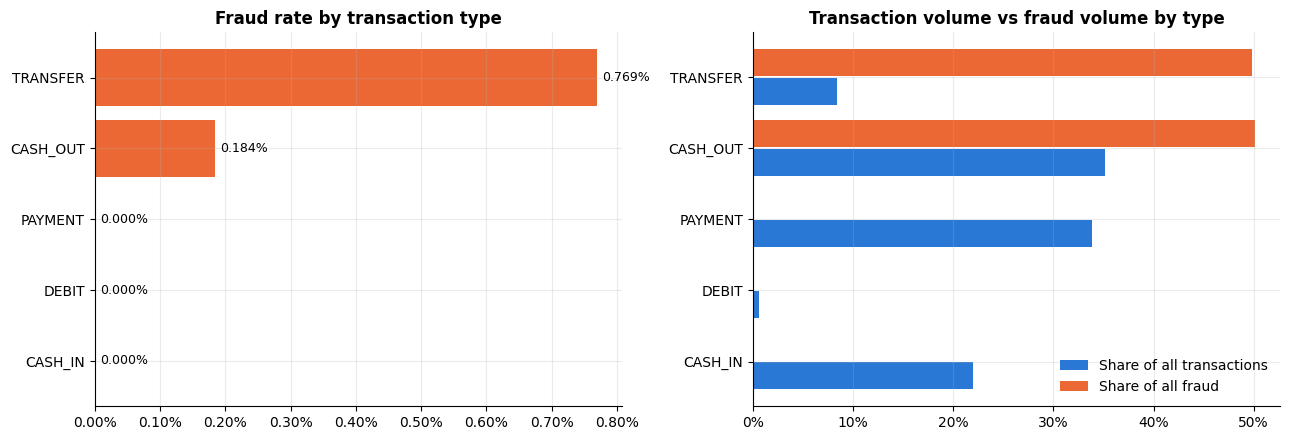

In [12]:
by_type = quality["fraud_by_type"]
by_type["share_of_all_tx_pct"] = by_type["transactions"] / by_type["transactions"].sum() * 100
display(by_type)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

order = by_type.sort_values("fraud_rate_pct").index
ax1.barh(order, by_type.loc[order, "fraud_rate_pct"], color=FRAUD)
ax1.set_title("Fraud rate by transaction type")
ax1.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=2))
for y, v in enumerate(by_type.loc[order, "fraud_rate_pct"]):
    ax1.annotate(f"{v:.3f}%", (v, y), xytext=(4, 0), textcoords="offset points", va="center", fontsize=9)

share = by_type[["share_of_all_tx_pct", "share_of_all_fraud_pct"]].loc[order]
y = np.arange(len(share))
ax2.barh(y - 0.2, share["share_of_all_tx_pct"], height=0.38, color=LEGIT, label="Share of all transactions")
ax2.barh(y + 0.2, share["share_of_all_fraud_pct"], height=0.38, color=FRAUD, label="Share of all fraud")
ax2.set_yticks(y, share.index)
ax2.xaxis.set_major_formatter(mtick.PercentFormatter())
ax2.set_title("Transaction volume vs fraud volume by type")
ax2.legend(loc="lower right", frameon=False)
plt.tight_layout()
plt.show()

> **Finding:** Fraud occurs in **only two types: TRANSFER and CASH_OUT**. CASH_IN, DEBIT and PAYMENT contain zero fraud.
> - TRANSFER has the highest fraud rate (**0.7688%**, 4,097 frauds), about 4× CASH_OUT (**0.1840%**, 4,116 frauds).
> - TRANSFER is only **8.38%** of all transactions but **49.88%** of all fraud, so it is heavily over-represented. CASH_OUT is 35.17% of transactions and 50.12% of fraud.
> - *Implication:* transaction type is a strong signal, and a model only needs to score TRANSFER and CASH_OUT. Whether to filter the other types out or keep them is a Phase 3 decision.

### Q3. How does transaction amount differ between fraudulent and legitimate transactions?
Compared **only within transaction types where fraud occurs**, so we are not comparing fraud against unrelated payment types. Amounts are heavily skewed, so the histogram uses a log scale.

Types with at least one fraud: ['TRANSFER', 'CASH_OUT']


,count,mean,std,min,25%,50%,75%,95%,99%,max
is_fraud,,,,,,,,,,
0,"2,762,196.0000","314,115.4962","877,144.1496",0.0100,"82,908.2325","171,034.4600","305,994.1850","942,414.6800","2,580,263.9160","92,445,516.6400"
1,"8,213.0000","1,467,967.2991","2,404,252.9472",0.0000,"127,091.3300","441,423.4400","1,517,771.4800","8,006,429.0400","10,000,000.0000","10,000,000.0000"


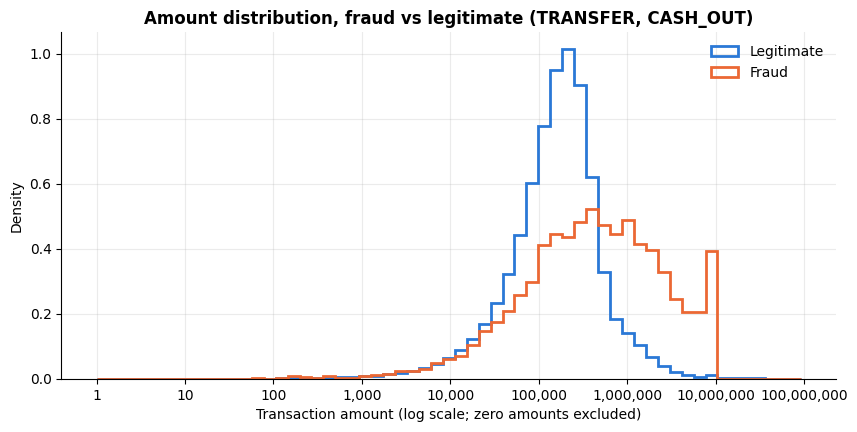

Most common fraud amounts:
amount
10,000,000.0000    287
0.0000              16
1,165,187.8900       4
429,257.4500         4
181.0000             2
Name: count, dtype: int64


In [13]:
fraud_types = by_type.index[by_type["fraud"] > 0].tolist()
in_scope = df[df["type"].isin(fraud_types)]
print("Types with at least one fraud:", fraud_types)

display(in_scope.groupby("is_fraud")["amount"].describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99]))

# Histogram of log10(amount) with equal-width bins, so density is comparable across the range.
# The 16 zero-amount rows cannot be log-transformed and are excluded from this chart only.
positive = in_scope[in_scope["amount"] > 0]
bins = np.linspace(0, np.log10(positive["amount"].max()), 60)
fig, ax = plt.subplots()
for label, color, name in [(0, LEGIT, "Legitimate"), (1, FRAUD, "Fraud")]:
    log_amounts = np.log10(positive.loc[positive["is_fraud"] == label, "amount"])
    ax.hist(log_amounts, bins=bins, density=True, histtype="step", linewidth=2, color=color, label=name)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{10**x:,.0f}"))
ax.set_xlabel("Transaction amount (log scale; zero amounts excluded)")
ax.set_ylabel("Density")
ax.set_title(f"Amount distribution, fraud vs legitimate ({', '.join(fraud_types)})")
ax.legend(frameon=False)
plt.show()

# Does the amount ever hit a ceiling? (check, don't assume)
print("Most common fraud amounts:")
print(in_scope.loc[in_scope["is_fraud"] == 1, "amount"].value_counts().head(5))

> **Finding:** Within TRANSFER/CASH_OUT, fraud amounts are larger: median **441,423** vs **171,034** for legitimate, mean **1.47M** vs **314K**. But the distributions overlap heavily (the fraud 25th percentile, 127,091, is below the legitimate median), so amount alone cannot separate the classes.
> - **Fraud amounts are capped at exactly 10,000,000:** 287 frauds sit exactly at the cap and none exceed it, while 2,443 legitimate transactions are above 10M (checked in section 3, Q7 cell). This looks like a simulator limit on fraud size.

### Q4. Is fraud concentrated at particular steps / times?
One step = one simulated hour. We look at the full timeline, then at hour-of-day (`step % 24`, which assumes the simulation starts at midnight; this is an assumption, not a documented fact).

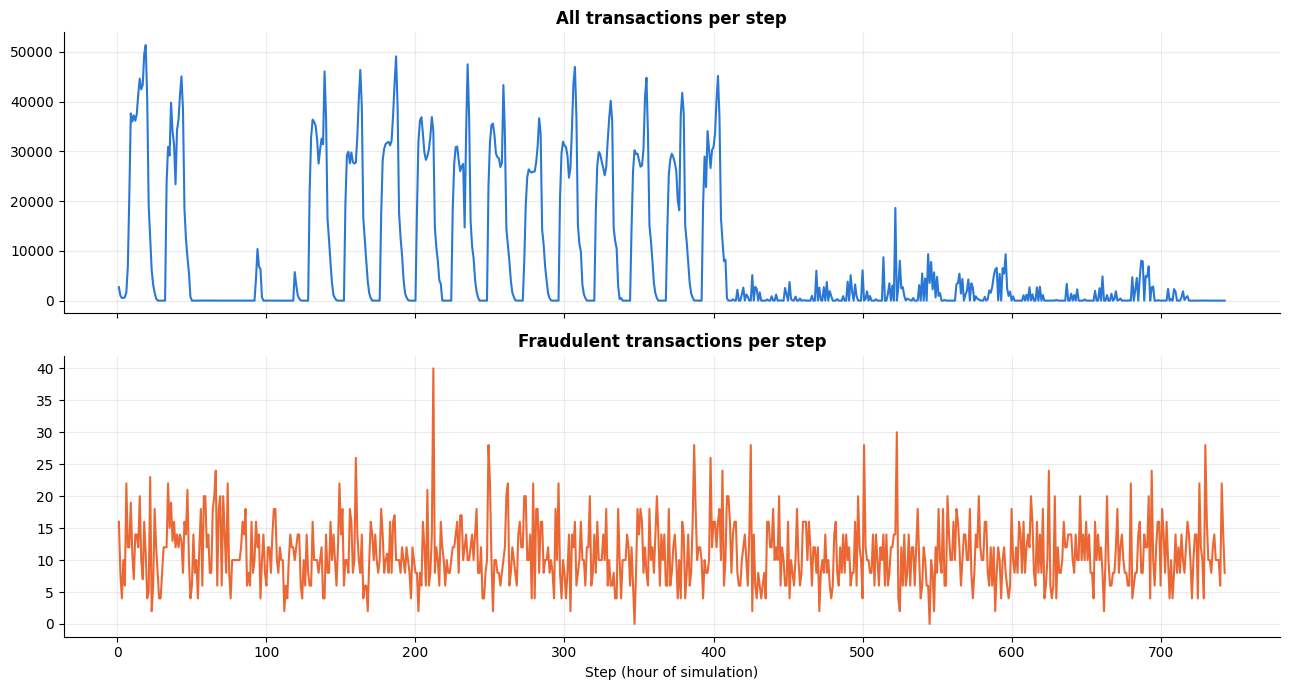

,transactions,fraud,fraud_rate_pct
step,,,
0,71587,300,0.4191
1,27111,358,1.3205
2,9018,372,4.1251
3,2007,326,16.2431
4,1241,274,22.0790
5,1641,366,22.3035
6,3420,358,10.4678
7,8988,328,3.6493
8,26915,368,1.3673


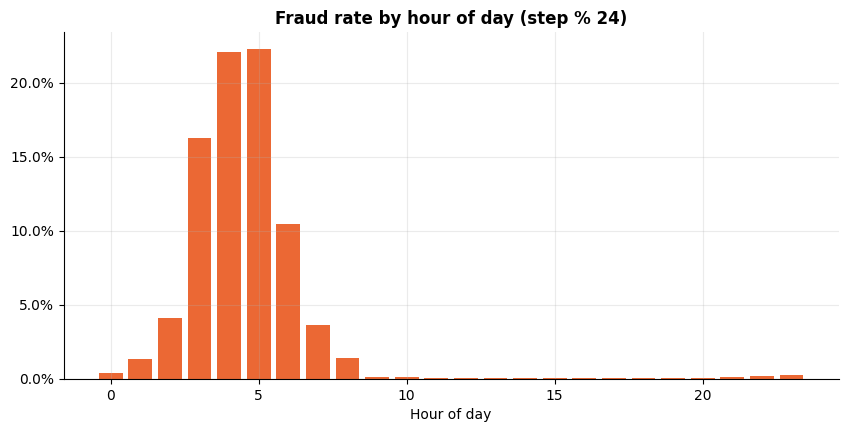

Steps with any transactions: 743 | steps containing fraud: 741
Fraud per step: median 10, min 0, max 40
Steps where EVERY transaction is fraud: 320


In [14]:
per_step = df.groupby("step")["is_fraud"].agg(transactions="size", fraud="sum")
per_step["fraud_rate_pct"] = per_step["fraud"] / per_step["transactions"] * 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
ax1.plot(per_step.index, per_step["transactions"], color=LEGIT, linewidth=1.5)
ax1.set_title("All transactions per step")
ax2.plot(per_step.index, per_step["fraud"], color=FRAUD, linewidth=1.5)
ax2.set_title("Fraudulent transactions per step")
ax2.set_xlabel("Step (hour of simulation)")
plt.tight_layout()
plt.show()

df_hour = df["step"] % 24
per_hour = df.groupby(df_hour)["is_fraud"].agg(transactions="size", fraud="sum")
per_hour["fraud_rate_pct"] = per_hour["fraud"] / per_hour["transactions"] * 100
display(per_hour)

fig, ax = plt.subplots()
ax.bar(per_hour.index, per_hour["fraud_rate_pct"], color=FRAUD)
ax.set_title("Fraud rate by hour of day (step % 24)")
ax.set_xlabel("Hour of day")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
plt.show()

print(f"Steps with any transactions: {df['step'].nunique()} | steps containing fraud: {df.loc[df['is_fraud'] == 1, 'step'].nunique()}")
print(f"Fraud per step: median {per_step['fraud'].median():.0f}, min {per_step['fraud'].min()}, max {per_step['fraud'].max()}")
print(f"Steps where EVERY transaction is fraud: {(per_step['fraud'] == per_step['transactions']).sum()}")

> **Finding:** Fraud volume is roughly **flat over time**, while legitimate volume is not:
> - By hour of day, fraud counts range only from 274 to 375. Legitimate volume ranges from 1,241 transactions at hour 4 to 647,814 at hour 19. The high fraud *rate* at hours 3–5 (16–22%) comes from low legitimate traffic, not from more fraud.
> - Fraud appears in 741 of 743 steps (median 10 per step). In **320 of 743 steps every transaction is fraud**: legitimate traffic largely stops in the later part of the simulation while fraud continues.
> - *Implication:* `step` (and hour-of-day) would let a model learn "late step means fraud", which is a simulation artefact rather than behaviour. This also affects the train/test split. A purely chronological split would put mostly fraud in the test set. Both points will be decided in Phase 3.

### Q5. What balance patterns occur before and after fraudulent transactions?
Within fraud-bearing types, compare the share of transactions showing each balance pattern.

,Legitimate %,Fraud %
origin_emptied (new_orig == 0),90.0951,98.0519
full_balance_moved (amount == old_orig),0.0001,97.8205
origin_zero_before (old_orig == 0),47.3732,0.4992
dest_zero_before_and_after,0.0618,49.6286


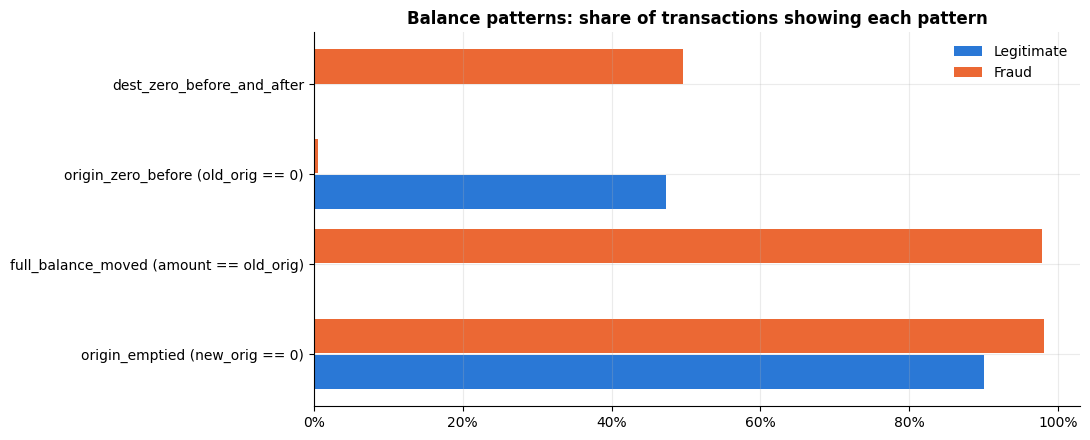

In [15]:
patterns = pd.DataFrame({
    "is_fraud": in_scope["is_fraud"],
    "origin_emptied (new_orig == 0)": in_scope["new_balance_orig"] == 0,
    "full_balance_moved (amount == old_orig)": np.isclose(in_scope["amount"], in_scope["old_balance_orig"]),
    "origin_zero_before (old_orig == 0)": in_scope["old_balance_orig"] == 0,
    "dest_zero_before_and_after": (in_scope["old_balance_dest"] == 0) & (in_scope["new_balance_dest"] == 0),
})
pattern_rates = patterns.groupby("is_fraud").mean().T * 100
pattern_rates.columns = ["Legitimate %", "Fraud %"]
display(pattern_rates)

y = np.arange(len(pattern_rates))
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.barh(y - 0.2, pattern_rates["Legitimate %"], height=0.38, color=LEGIT, label="Legitimate")
ax.barh(y + 0.2, pattern_rates["Fraud %"], height=0.38, color=FRAUD, label="Fraud")
ax.set_yticks(y, pattern_rates.index)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("Balance patterns: share of transactions showing each pattern")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

> **Finding:** Balance patterns are the strongest differentiator found so far (within TRANSFER/CASH_OUT):
> - **Whole origin balance moved** (amount = old origin balance): **97.82% of fraud vs 0.0001% of legitimate.**
> - **Destination 0 → 0 despite receiving money:** 49.63% of fraud vs 0.06% of legitimate.
> - **Origin had zero balance beforehand:** 0.50% of fraud vs 47.37% of legitimate.
> - "Origin emptied" barely separates the classes (98.05% vs 90.10%), because legitimate balances are also floored at 0 (see section 2).
> - *Caution:* a near-perfect pattern like "whole balance moved" probably reflects how PaySim's fraud agent was coded (empty the victim's account). It will make metrics look excellent but may not carry over to real fraud. We will report this as a limitation rather than celebrate it.

### Q7. What behavioural characteristics differentiate fraud from legitimate transactions?
- **Fraction of origin balance moved:** do fraudsters drain accounts?
- **Account reuse:** do fraud origin/destination accounts appear repeatedly, or are they one-off?

In [16]:
has_balance = in_scope["old_balance_orig"] > 0
frac_moved = (in_scope.loc[has_balance, "amount"] / in_scope.loc[has_balance, "old_balance_orig"]).clip(upper=10)
display(frac_moved.groupby(in_scope.loc[has_balance, "is_fraud"]).describe(percentiles=[0.25, 0.5, 0.75]))

orig_counts = df["name_orig"].value_counts()
dest_counts = df["name_dest"].value_counts()
fraud_rows = df[df["is_fraud"] == 1]
reuse = pd.DataFrame({
    "origin accounts used >1 time (%)": [
        (orig_counts[df.loc[df["is_fraud"] == 0, "name_orig"].unique()] > 1).mean() * 100,
        (orig_counts[fraud_rows["name_orig"].unique()] > 1).mean() * 100,
    ],
    "destination accounts used >1 time (%)": [
        (dest_counts[df.loc[df["is_fraud"] == 0, "name_dest"].unique()] > 1).mean() * 100,
        (dest_counts[fraud_rows["name_dest"].unique()] > 1).mean() * 100,
    ],
}, index=["Legitimate", "Fraud"])
display(reuse)

fraud_tx = fraud_rows[fraud_rows["type"] == "TRANSFER"][["step", "amount"]]
fraud_co = fraud_rows[fraud_rows["type"] == "CASH_OUT"][["step", "amount"]]
# Count TRANSFER rows (not distinct step/amount pairs: several frauds can share both).
cashout_keys = pd.MultiIndex.from_frame(fraud_co)
chained = pd.MultiIndex.from_frame(fraud_tx).isin(cashout_keys)
print(f"Fraud TRANSFERs with a fraud CASH_OUT of the same amount in the same step: {chained.sum():,} of {len(fraud_tx):,}")
print(f"Fraud amounts > 10M: {(fraud_rows['amount'] > 10_000_000).sum()} | "
      f"legitimate amounts > 10M: {((df['is_fraud'] == 0) & (df['amount'] > 10_000_000)).sum():,}")

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,"1,453,655.0000",5.7252,4.0137,0.0000,1.5132,5.7758,10.0000,10.0000
1,"8,172.0000",0.9952,0.1583,0.0384,1.0000,1.0000,1.0000,10.0000


,origin accounts used >1 time (%),destination accounts used >1 time (%)
Legitimate,0.1465,16.9010
Fraud,0.3409,67.2787


Fraud TRANSFERs with a fraud CASH_OUT of the same amount in the same step: 4,078 of 4,097
Fraud amounts > 10M: 0 | legitimate amounts > 10M: 2,443


> **Finding:**
> - **Fraud drains the account:** amount ÷ origin balance has a median of **1.00** for fraud (the 25th and 75th percentiles are also 1.00). For legitimate transactions the median is 5.78 (clipped at 10), because legitimate amounts usually exceed the recorded balance.
> - **Transfer-then-cash-out:** 4,078 of 4,097 fraud TRANSFERs (99.5%) have a fraud CASH_OUT of the same amount in the same step. This matches the documented fraud scenario: take over an account, transfer the funds to a mule account, then cash out.
> - **Destination reuse:** 67.28% of fraud destination accounts appear more than once, vs 16.90% of legitimate ones. *Leakage warning:* these counts use the whole dataset, including future transactions. A usable feature would have to count only *prior* activity at prediction time.
> - Origin accounts are almost never reused (0.15% legitimate, 0.34% fraud), so origin history adds little. Account IDs themselves must not be features: the model would just memorise identities.

## 4. Summary

### Data-quality issues to resolve in Phase 2
| Issue | Size | Proposed handling |
|---|---|---|
| Zero-amount "fraud" CASH_OUTs | 16 rows | Exclude from modelling (no money moved, so it is not a learnable transaction). Keep a record of them in SQL analysis. |
| Amount exceeds origin balance; balance floored at 0 | 90.10% of legit TRANSFER/CASH_OUT | **Keep.** This is how the simulator works, not corruption. Document it as a limitation and capture it as an explicit feature rather than dropping rows. |
| Merchant destination balances always 0 | all PAYMENT rows | Keep. Treat destination balance as "not available" for merchants. |
| Customer destination 0 → 0 on non-zero amount | 0.07–11.43% by type | Keep. Turn it into a balance-inconsistency indicator feature. |
| `is_flagged_fraud` doesn't match its described rule | 16 flags | Exclude from features (see leakage list). Report it as the "existing rule" baseline: 0.19% recall. |

### Early hypotheses for feature engineering (Phase 3)
- `type` (TRANSFER vs CASH_OUT): fraud rate differs about 4× between them.
- Fraction of origin balance moved, and an "entire balance moved" flag: 97.82% vs 0.0001%.
- Origin and destination balance-error terms (expected vs actual balance change).
- Destination 0 → 0 indicator: 49.63% vs 0.06%.
- `amount` (log-scaled): it helps, but the classes overlap.

### Columns to review for leakage
- `is_flagged_fraud`: the output of another fraud system and nearly a copy of the label for the rows it flags. Exclude it.
- `name_orig` / `name_dest`: identifiers, not behaviour, so the model would memorise them. Exclude them.
- `step` / hour-of-day: a simulation artefact (320 steps are 100% fraud). Exclude it, or justify it carefully.
- Account-reuse counts: only valid if computed from *prior* transactions.
- `new_balance_*`: post-transaction values. Phase 3 must decide whether they are known at scoring time (a pre-authorisation system would not know them).